In [1]:
import sys, subprocess, importlib

print("Python executable:", sys.executable)
print("Python version   :", sys.version)

# Packages your project needs (based on your src files)
required = [
    "numpy",
    "cv2",          # opencv-python installs module name "cv2"
    "torch",
    "torchvision",
    "tqdm",
    "matplotlib",
    "ipykernel",
]

missing = []
for mod in required:
    try:
        importlib.import_module(mod)
    except Exception:
        missing.append(mod)

if missing:
    print("Missing modules:", missing)
    # Map import names to pip package names
    pip_map = {
        "cv2": "opencv-python",
        "torch": "torch",
        "torchvision": "torchvision",
        "tqdm": "tqdm",
        "matplotlib": "matplotlib",
        "numpy": "numpy",
        "ipykernel": "ipykernel",
    }
    pkgs = [pip_map[m] for m in missing]
    print("Installing via pip:", pkgs)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])
    print("Install complete.")
else:
    print("All required modules already installed.")


Python executable: e:\dl_cv_mini_project\road_lane_detection\venv\Scripts\python.exe
Python version   : 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
All required modules already installed.


In [2]:
import os
from pathlib import Path

print("Initial CWD:", os.getcwd())

# If the notebook is opened from notebooks/, move to project root
if Path("src").exists() is False and Path("..").exists():
    os.chdir("..")

print("Final CWD:", os.getcwd())

# Sanity checks (must all be True)
print("src exists        :", Path("src").exists())
print("data exists       :", Path("data").exists())
print("models exists     :", Path("models").exists())
print("venv exists       :", Path("venv").exists())


Initial CWD: e:\dl_cv_mini_project\road_lane_detection\src
Final CWD: e:\dl_cv_mini_project\road_lane_detection
src exists        : True
data exists       : True
models exists     : True
venv exists       : True


In [3]:
# Core project imports (must succeed)
from src.models import UNetSmall
from src.dataset import TuSimpleSegmentationDataset

print("Imports OK — project modules are accessible")


Imports OK — project modules are accessible


In [4]:
from pathlib import Path

raw_root = Path("data/raw/tusimple")
proc_root = Path("data/processed/tusimple")

print("=== RAW DATA STATUS ===")
print("Raw root exists:", raw_root.exists())
if raw_root.exists():
    print("Raw root contents:", [p.name for p in raw_root.iterdir()])

print("\n=== PROCESSED DATA STATUS ===")
print("Processed root exists:", proc_root.exists())
if proc_root.exists():
    print("Processed root contents:", [p.name for p in proc_root.iterdir()])

splits = proc_root / "splits"
if splits.exists():
    print("Split files:", [p.name for p in splits.iterdir()])


=== RAW DATA STATUS ===
Raw root exists: True
Raw root contents: ['test_label.json', 'test_label_new.json', 'test_set', 'train_set']

=== PROCESSED DATA STATUS ===
Processed root exists: True
Processed root contents: ['images', 'masks', 'splits']
Split files: ['train.txt', 'val.txt']


In [5]:
from src.dataset import TuSimpleSegmentationDataset

# Initialize dataset exactly as used in training
ds = TuSimpleSegmentationDataset(
    root="data/processed/tusimple",
    split="train",
    img_size=(360, 640)
)

print("Number of training samples:", len(ds))

# Load one sample
x, y = ds[0]

print("Image tensor shape:", x.shape, "| dtype:", x.dtype)
print("Mask tensor shape :", y.shape, "| dtype:", y.dtype)


Number of training samples: 3264
Image tensor shape: torch.Size([3, 360, 640]) | dtype: torch.float32
Mask tensor shape : torch.Size([1, 360, 640]) | dtype: torch.float32


In [6]:
import subprocess
import sys

cmd = [sys.executable, "-m", "src.prepare_tusimple"]
print("Running command:", " ".join(cmd))

# Run the preprocessing script exactly as from terminal
result = subprocess.run(cmd, text=True)
result.check_returncode()


Running command: e:\dl_cv_mini_project\road_lane_detection\venv\Scripts\python.exe -m src.prepare_tusimple


In [8]:
import sys
import subprocess
import re
import time

cmd = [sys.executable, "-m", "src.train"]
print("Running:", " ".join(cmd))
print("----- LIVE LOG START -----")

# Start process with line-buffered output
p = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    universal_newlines=True
)

# Optional: simple epoch counter display (works if your script prints "Epoch X" lines)
epoch_pattern = re.compile(r"(epoch\s*\(?\s*)(\d+)(\s*[\)/]?\s*)(?:of\s*)?(\d+)?", re.IGNORECASE)

last_epoch_seen = None
total_epochs_seen = None
start_time = time.time()

try:
    for line in p.stdout:
        line_stripped = line.rstrip()
        print(line_stripped)

        # Try to parse epoch progress if present in logs
        m = epoch_pattern.search(line_stripped)
        if m:
            current_epoch = int(m.group(2))
            total_epochs = m.group(4)
            last_epoch_seen = current_epoch
            if total_epochs is not None:
                try:
                    total_epochs_seen = int(total_epochs)
                except:
                    pass

            elapsed = time.time() - start_time
            if total_epochs_seen:
                remaining = total_epochs_seen - last_epoch_seen
                print(f"[Progress] Epoch {last_epoch_seen}/{total_epochs_seen} | Remaining: {remaining} | Elapsed: {elapsed:.1f}s")
            else:
                print(f"[Progress] Epoch {last_epoch_seen} | Elapsed: {elapsed:.1f}s")

    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"Training failed with return code {p.returncode}")

finally:
    if p.stdout:
        p.stdout.close()

print("----- LIVE LOG END -----")
print("Training finished successfully.")


Running: e:\dl_cv_mini_project\road_lane_detection\venv\Scripts\python.exe -m src.train
----- LIVE LOG START -----

Epoch 1/10 [train]:   0%|          | 0/408 [00:00<?, ?it/s]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 6.9s
Epoch 1/10 [train]:   0%|          | 0/408 [00:04<?, ?it/s, loss=0.85]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 6.9s
Epoch 1/10 [train]:   0%|          | 1/408 [00:04<28:04,  4.14s/it, loss=0.85]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 7.3s
Epoch 1/10 [train]:   0%|          | 1/408 [00:04<28:04,  4.14s/it, loss=0.801]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 7.3s
Epoch 1/10 [train]:   0%|          | 2/408 [00:04<12:55,  1.91s/it, loss=0.801]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 7.6s
Epoch 1/10 [train]:   0%|          | 2/408 [00:04<12:55,  1.91s/it, loss=0.773]
[Progress] Epoch 1/10 | Remaining: 9 | Elapsed: 7.6s
Epoch 1/10 [train]:   1%|          | 3/408 [00:04<08:05,  1.20s/it, loss=0.773]
[Progress] Epoch 1/10 | Remaining: 9

In [9]:
from pathlib import Path

ckpt_dir = Path("models/checkpoints")
ckpts = sorted(ckpt_dir.glob("*.pt"), key=lambda p: p.stat().st_mtime, reverse=True)

print("Checkpoint dir:", ckpt_dir.resolve())
print("Found:", len(ckpts), "checkpoint(s)")
for p in ckpts[:10]:
    print(p.name, "|", p.stat().st_mtime)


Checkpoint dir: E:\dl_cv_mini_project\road_lane_detection\models\checkpoints
Found: 11 checkpoint(s)
unet_tusimple_epoch10.pt | 1767098026.946417
unet_tusimple_epoch9.pt | 1767097872.150688
unet_tusimple_epoch8.pt | 1767097717.3905625
unet_tusimple_best.pt | 1767097562.675909
unet_tusimple_epoch7.pt | 1767097562.6605892
unet_tusimple_epoch6.pt | 1767097407.8708813
unet_tusimple_epoch5.pt | 1767097252.8522263
unet_tusimple_epoch4.pt | 1767097098.031781
unet_tusimple_epoch3.pt | 1767096943.4118195
unet_tusimple_epoch2.pt | 1767096786.4141452


In [12]:
import subprocess, sys

cmd = [sys.executable, "-m", "src.evaluate"]
result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)
print(result.stderr)


Val IoU      : 0.4284
Val Dice     : 0.5926
Val Accuracy : 0.9840
Val Precision: 0.6926
Val Recall   : 0.5242
Val F1 Score : 0.5926

e:\dl_cv_mini_project\road_lane_detection\src\evaluate.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an iss

In [15]:
import subprocess, sys

cmd = [sys.executable, "-m", "src.plot_values"]
result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)
print(result.stderr)

import matplotlib.pyplot as plt
plt.show()


Epoch 01 | loss=0.0714 iou=0.2576 dice=0.3998 prec=0.5973 rec=0.3168 f1=0.3998
Epoch 02 | loss=0.0503 iou=0.3636 dice=0.5253 prec=0.6763 rec=0.4375 f1=0.5253
Epoch 03 | loss=0.0511 iou=0.3318 dice=0.4882 prec=0.6741 rec=0.3955 f1=0.4882
Epoch 04 | loss=0.0455 iou=0.3901 dice=0.5522 prec=0.6760 rec=0.4789 f1=0.5521
Epoch 05 | loss=0.0422 iou=0.4191 dice=0.5833 prec=0.6752 rec=0.5197 f1=0.5833
Epoch 06 | loss=0.0425 iou=0.4193 dice=0.5828 prec=0.6740 rec=0.5219 f1=0.5828
Epoch 07 | loss=0.0399 iou=0.4284 dice=0.5926 prec=0.6926 rec=0.5242 f1=0.5926
Epoch 08 | loss=0.0392 iou=0.4230 dice=0.5874 prec=0.7030 rec=0.5124 f1=0.5874
Epoch 09 | loss=0.0400 iou=0.4135 dice=0.5774 prec=0.6918 rec=0.5018 f1=0.5774
Epoch 10 | loss=0.0427 iou=0.4139 dice=0.5776 prec=0.6875 rec=0.5062 f1=0.5776
Figure(700x400)
Figure(700x400)
Figure(700x400)

e:\dl_cv_mini_project\road_lane_detection\src\plot_values.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value)

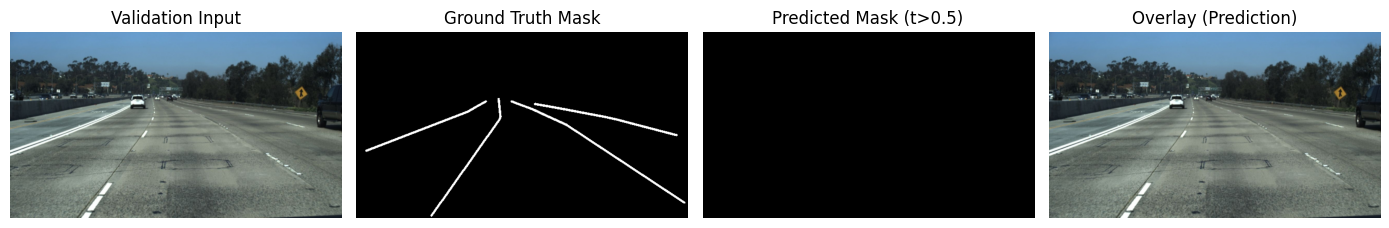

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import TuSimpleSegmentationDataset

# -----------------------------
# SETTINGS (match your notebook)
# -----------------------------
VAL_INDEX = 3
THRESH = 0.5
device = "cuda" if torch.cuda.is_available() else "cpu"

# model is already loaded in your notebook, so only ensure this:
model = model.to(device)
model.eval()

# -----------------------------
# LOAD VALIDATION SAMPLE
# -----------------------------
val_ds = TuSimpleSegmentationDataset(split="val")   # keep as your project defines it
x, y = val_ds[VAL_INDEX]                            # x: image tensor, y: mask tensor

# Ensure shapes: x [C,H,W], y [1,H,W] or [H,W]
if isinstance(x, np.ndarray):
    x = torch.from_numpy(x)
if isinstance(y, np.ndarray):
    y = torch.from_numpy(y)

x = x.float().to(device)
y = y.float()

# Add batch dim
xb = x.unsqueeze(0)

# -----------------------------
# INFERENCE
# -----------------------------
with torch.no_grad():
    out = model(xb)

# If model outputs logits, apply sigmoid
pred_prob = torch.sigmoid(out)

# Binary mask
pred_bin = (pred_prob > THRESH).float()

# -----------------------------
# PREP FOR DISPLAY
# -----------------------------
# image back to HWC for plotting
img_np = x.detach().cpu().numpy()
img_np = np.transpose(img_np, (1, 2, 0))
img_np = np.clip(img_np, 0, 1)

# ground-truth mask to HW
gt_np = y.detach().cpu().numpy()
if gt_np.ndim == 3:
    gt_np = gt_np.squeeze(0)
gt_np = (gt_np > 0.5).astype(np.uint8)

# predicted mask to HW
pred_np = pred_bin.squeeze().detach().cpu().numpy()
if pred_np.ndim == 3:
    pred_np = pred_np.squeeze(0)
pred_np = pred_np.astype(np.uint8)

# overlay (pred in red)
overlay = img_np.copy()
overlay[pred_np == 1] = [1, 0, 0]

# -----------------------------
# VISUALIZE
# -----------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.title("Validation Input")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask")
plt.imshow(gt_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title(f"Predicted Mask (t>{THRESH})")
plt.imshow(pred_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Overlay (Prediction)")
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()


## hough transforrm

In [19]:
import cv2
import numpy as np

def unet_to_hough_lines(
    img_rgb_uint8: np.ndarray,
    pred_prob_hw: np.ndarray,
    thresh: float = 0.35,
    min_line_length: int = 40,
    max_line_gap: int = 25,
):
    """
    img_rgb_uint8: (H,W,3) RGB uint8 image (same size as pred_prob_hw)
    pred_prob_hw : (H,W) float array in [0,1] (UNet sigmoid output)
    returns: overlay_rgb_uint8, lines_p
    """
    H, W = pred_prob_hw.shape[:2]

    # 1) Binary mask from UNet probabilities
    mask = (pred_prob_hw >= thresh).astype(np.uint8) * 255

    # 2) Clean mask (remove speckles + connect lane segments)
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close, iterations=2)

    # 3) Edges on mask + ROI + Hough
    edges = cv2.Canny(mask, 50, 150)

    roi = np.zeros_like(edges)
    poly = np.array([[
        (int(0.05 * W), H),
        (int(0.45 * W), int(0.60 * H)),
        (int(0.55 * W), int(0.60 * H)),
        (int(0.95 * W), H),
    ]], dtype=np.int32)
    cv2.fillPoly(roi, poly, 255)
    edges_roi = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(
        edges_roi,
        rho=1,
        theta=np.pi / 180,
        threshold=30,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    # Draw lines on overlay
    overlay = img_rgb_uint8.copy()
    if lines is not None:
        for x1, y1, x2, y2 in lines.reshape(-1, 4):
            cv2.line(overlay, (x1, y1), (x2, y2), (255, 0, 0), 3)  # RGB red

    return overlay, lines


# --------------------------
# USAGE (inside your notebook)
# --------------------------
# after inference:
# pred_prob = torch.sigmoid(out).squeeze().detach().cpu().numpy()  # (H,W) float
# img_np    = np.transpose(x.detach().cpu().numpy(), (1,2,0))      # (H,W,3) float in [0,1]
# img_u8    = (np.clip(img_np, 0, 1) * 255).astype(np.uint8)

# overlay_u8, lines = unet_to_hough_lines(img_u8, pred_prob, thresh=0.35)

# visualize
# import matplotlib.pyplot as plt
# plt.figure(figsize=(7,4)); plt.imshow(overlay_u8); plt.axis("off"); plt.show()


In [22]:
with torch.no_grad():
    out = model(x.unsqueeze(0).to(device))

pred_prob = torch.sigmoid(out).squeeze().detach().cpu().numpy()


In [23]:
img_np = x.detach().cpu().numpy()          # x: [C,H,W]
img_np = np.transpose(img_np, (1, 2, 0))   # -> [H,W,3]
img_np = np.clip(img_np, 0, 1)

img_u8 = (img_np * 255).astype(np.uint8)



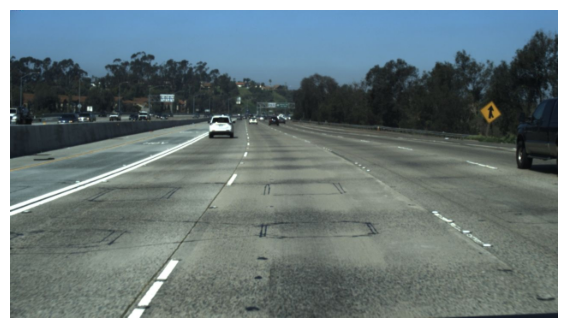

In [25]:
overlay_u8, lines = unet_to_hough_lines(
    img_u8,
    pred_prob,
    thresh=0.25
)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.imshow(overlay_u8)
plt.axis("off")
plt.show()


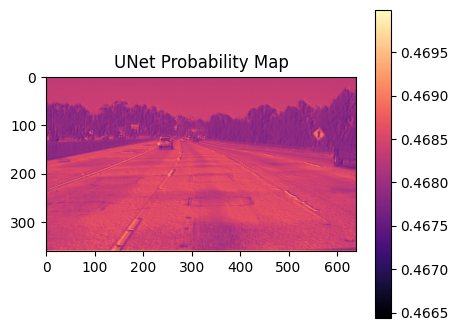

In [26]:
plt.figure(figsize=(5,4))
plt.imshow(pred_prob, cmap="magma")
plt.colorbar()
plt.title("UNet Probability Map")
plt.show()


In [34]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        inter = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


In [35]:
from src.dataset import TuSimpleSegmentationDataset
from torch.utils.data import DataLoader

train_ds = TuSimpleSegmentationDataset(split="train")

def compute_pos_weight(dataset, max_batches=200):
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    pos, neg = 0, 0

    for i, (_, y) in enumerate(loader):
        if i >= max_batches:
            break
        y = y.float()
        pos += y.sum().item()
        neg += (1 - y).sum().item()

    return neg / (pos + 1e-8)

POS_W = compute_pos_weight(train_ds)
print("POS_W:", POS_W)


POS_W: 43.8913390670945


In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([POS_W], device=device)
)
dice = DiceLoss()

def loss_fn(logits, targets):
    return 0.5 * bce(logits, targets) + 0.5 * dice(logits, targets)
